# 03_embeddings

Notebook 3 — Cell State Shift Analysis
========================
Quantifies tumor-induced transcriptional shifts per cell type across all three representations (scGPT, PCA-50, Row-HVG).

```
Inputs:
    PDAC_ADJ_embeddings.h5ad   (output of Notebook 2)

Outputs:
    shift_results.csv                    -- per cell type shift magnitudes
    shift_ranking_barplot.png            -- ranked bar chart (all 3 reps)
    shift_heatmap.png                    -- cell type x representation heatmap
    shift_scatter_scgpt_vs_pca.png       -- scGPT vs PCA shift correlation
    umap_shift_vectors.png               -- mean ADJ/PDAC centroids on UMAP

Answers:
    RQ1 -- which cell types shift most between ADJ and PDAC?
    RQ2 -- does scGPT capture larger/more meaningful shifts than PCA/Raw-HVG?
```

In [2]:
# Cell 1 — run then Runtime -> Restart session
!pip uninstall -y numpy
!pip install "numpy<2" -q
!pip install "scanpy==1.10.4" anndata scikit-learn scipy \
    umap-learn matplotlib seaborn -q

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>

In [1]:
# ======================================================================
# CELL 1 - Imports
# ======================================================================

import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.spatial.distance import cosine

print(f"Scanpy {sc.__version__}")


/usr/local/lib/python3.12/dist-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/usr/local/lib/python3.12/dist-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/usr/local/lib/python3.12/dist-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


Scanpy 1.10.4


In [2]:
# ======================================================================
# CELL 2 - Config
# ======================================================================

from google.colab import drive
drive.mount("/content/drive")

DATA_DIR      = Path("/content/drive/MyDrive/CompGenProject/data")
EMBED_FILE    = DATA_DIR / "PDAC_ADJ_embeddings.h5ad"

CELL_TYPE_KEY = "scGPT_target_label"
MIN_CELLS     = 10      # minimum cells per condition per cell type to include
RANDOM_STATE  = 42

print(f"Input : {EMBED_FILE}  (exists: {EMBED_FILE.exists()})")

Mounted at /content/drive
Input : /content/drive/MyDrive/CompGenProject/data/PDAC_ADJ_embeddings.h5ad  (exists: True)


In [3]:
# ======================================================================
# CELL 3 - Load embeddings
# ======================================================================

print("\n-- Loading embeddings -----------------------------------------------")
adata = sc.read_h5ad(EMBED_FILE)
print(f"  Shape     : {adata.shape}")
print(f"  obsm keys : {list(adata.obsm.keys())}")
print(f"  Cell types: {sorted(adata.obs[CELL_TYPE_KEY].unique())}")
print(f"  Conditions: {adata.obs['condition'].value_counts().to_dict()}")

# Representations to compare
REPS = {
    "scGPT":   adata.obsm["X_scgpt"],
    "PCA-50":  adata.obsm["X_pca50"],
    "Raw-HVG": adata.obsm["X_raw_hvg"],
}

CELL_TYPES = sorted(adata.obs[CELL_TYPE_KEY].dropna().unique())
print(f"\n  Representations loaded:")
for name, X in REPS.items():
    print(f"    {name:10s}  shape={X.shape}")


-- Loading embeddings -----------------------------------------------
  Shape     : (71074, 3000)
  obsm keys : ['X_pca', 'X_pca50', 'X_raw_hvg', 'X_scgpt', 'X_umap']
  Cell types: ['Acinar', 'B-Cells', 'Ductal', 'Endocrine', 'Endothelial', 'Fibroblasts', 'Macrophages', 'Mast', 'NK', 'Neutrophils', 'Plasma', 'Schwann', 'Stellate', 'T-Cells']
  Conditions: {'PDAC': 38074, 'ADJ': 33000}

  Representations loaded:
    scGPT       shape=(71074, 512)
    PCA-50      shape=(71074, 50)
    Raw-HVG     shape=(71074, 3000)


### Compute per cell-type shift magnitudes:
- Represents how much a cell type's avg transcriptional state changes when it goes from normal tissue to tumor tissue.
- A large shift means the tumor is heavily reprogramming that cell type's gene expression; the cells look transcriptionally different in the two conditions.
A small shift means the cell type is relatively stable regardless of whether it's in tumor or noaml tissue.

In [4]:
# ======================================================================
# CELL 4 - Compute per-cell-type shift magnitudes
# ======================================================================

print("\n-- Computing ADJ -> PDAC shift per cell type ------------------------")

results = []

for rep_name, X_all in REPS.items():
    for ct in CELL_TYPES:

        mask_pdac = (
            (adata.obs[CELL_TYPE_KEY] == ct) &
            (adata.obs["condition"]   == "PDAC")
        ).values
        mask_adj = (
            (adata.obs[CELL_TYPE_KEY] == ct) &
            (adata.obs["condition"]   == "ADJ")
        ).values

        n_pdac = mask_pdac.sum()
        n_adj  = mask_adj.sum()

        # Skip cell types with too few cells in either condition
        if n_pdac < MIN_CELLS or n_adj < MIN_CELLS:
            print(f"  Skipping {ct} ({rep_name}): "
                  f"PDAC n={n_pdac}, ADJ n={n_adj} (below MIN_CELLS={MIN_CELLS})")
            continue

        mu_pdac = X_all[mask_pdac].mean(axis=0)
        mu_adj  = X_all[mask_adj].mean(axis=0)

        delta         = mu_pdac - mu_adj
        euclidean     = np.linalg.norm(delta)
        cosine_dist   = cosine(mu_pdac, mu_adj)

        # Per-dimension variance within each condition (measures spread)
        var_pdac = X_all[mask_pdac].var(axis=0).mean()
        var_adj  = X_all[mask_adj].var(axis=0).mean()

        results.append({
            "representation": rep_name,
            "cell_type":      ct,
            "euclidean_shift": euclidean,
            "cosine_shift":    cosine_dist,
            "n_pdac":          n_pdac,
            "n_adj":           n_adj,
            "mean_var_pdac":   var_pdac,
            "mean_var_adj":    var_adj,
            # Direction vector (used later for UMAP arrows)
            "_mu_pdac":        mu_pdac,
            "_mu_adj":         mu_adj,
        })

shift_df = pd.DataFrame(results)

# Save direction vectors separately, keep main df clean
vectors_df = shift_df[["representation", "cell_type", "_mu_pdac", "_mu_adj"]].copy()
shift_df   = shift_df.drop(columns=["_mu_pdac", "_mu_adj"])

print(f"\n  Results shape: {shift_df.shape}")
print(shift_df[shift_df["representation"] == "scGPT"]
      .sort_values("euclidean_shift", ascending=False)
      [["cell_type", "euclidean_shift", "cosine_shift", "n_pdac", "n_adj"]]
      .to_string(index=False))

# Save results
shift_df.to_csv("shift_results.csv", index=False)
print("\n  Saved -> shift_results.csv")


-- Computing ADJ -> PDAC shift per cell type ------------------------
  Skipping Acinar (scGPT): PDAC n=0, ADJ n=8315 (below MIN_CELLS=10)
  Skipping Endocrine (scGPT): PDAC n=0, ADJ n=407 (below MIN_CELLS=10)
  Skipping NK (scGPT): PDAC n=0, ADJ n=405 (below MIN_CELLS=10)
  Skipping Plasma (scGPT): PDAC n=708, ADJ n=0 (below MIN_CELLS=10)
  Skipping Schwann (scGPT): PDAC n=187, ADJ n=0 (below MIN_CELLS=10)
  Skipping Acinar (PCA-50): PDAC n=0, ADJ n=8315 (below MIN_CELLS=10)
  Skipping Endocrine (PCA-50): PDAC n=0, ADJ n=407 (below MIN_CELLS=10)
  Skipping NK (PCA-50): PDAC n=0, ADJ n=405 (below MIN_CELLS=10)
  Skipping Plasma (PCA-50): PDAC n=708, ADJ n=0 (below MIN_CELLS=10)
  Skipping Schwann (PCA-50): PDAC n=187, ADJ n=0 (below MIN_CELLS=10)
  Skipping Acinar (Raw-HVG): PDAC n=0, ADJ n=8315 (below MIN_CELLS=10)
  Skipping Endocrine (Raw-HVG): PDAC n=0, ADJ n=407 (below MIN_CELLS=10)
  Skipping NK (Raw-HVG): PDAC n=0, ADJ n=405 (below MIN_CELLS=10)
  Skipping Plasma (Raw-HVG): PDA

In [5]:
# Pretending the largest shiftcell type
shift_df.iloc[np.argmax(shift_df['euclidean_shift'])]

,10
representation,PCA-50
cell_type,Ductal
euclidean_shift,24.155865
cosine_shift,0.699911
n_pdac,7237
n_adj,3881
mean_var_pdac,12.087977
mean_var_adj,5.677005


Ductal cells shifting the most makes biological sense since PDAC originates from ductal cells.

Notes:
- Quantifiable shifts:
  9 cell types above (cells present in both conditions)
- Condition-exclusive cell types (absent in other condition):
  5 cell types (below)


Other:
- Euclidean distance is more of a stronger measure than Cosine measure
- Euclidean captures both direction and magnitude. Cosine only captures direction as it normalizes out the magnitude.

In [6]:
condition_exclusive = {
    "ADJ only  (lost in PDAC)":     ["Acinar", "Endocrine", "NK"],
    "PDAC only (gained in tumor)":  ["Plasma", "Schwann"],
}

print("\n-- Condition-exclusive cell types (max shift -- absent in other condition) --")
for label, cts in condition_exclusive.items():
    print(f"\n  {label}:")
    for ct in cts:
        mask = adata.obs[CELL_TYPE_KEY] == ct
        n_pdac = (mask & (adata.obs["condition"] == "PDAC")).sum()
        n_adj  = (mask & (adata.obs["condition"] == "ADJ")).sum()
        print(f"    {ct:15s}  PDAC n={n_pdac:5d}  ADJ n={n_adj:5d}")


-- Condition-exclusive cell types (max shift -- absent in other condition) --

  ADJ only  (lost in PDAC):
    Acinar           PDAC n=    0  ADJ n= 8315
    Endocrine        PDAC n=    0  ADJ n=  407
    NK               PDAC n=    0  ADJ n=  405

  PDAC only (gained in tumor):
    Plasma           PDAC n=  708  ADJ n=    0
    Schwann          PDAC n=  187  ADJ n=    0



-- Plotting ranked bar chart ----------------------------------------


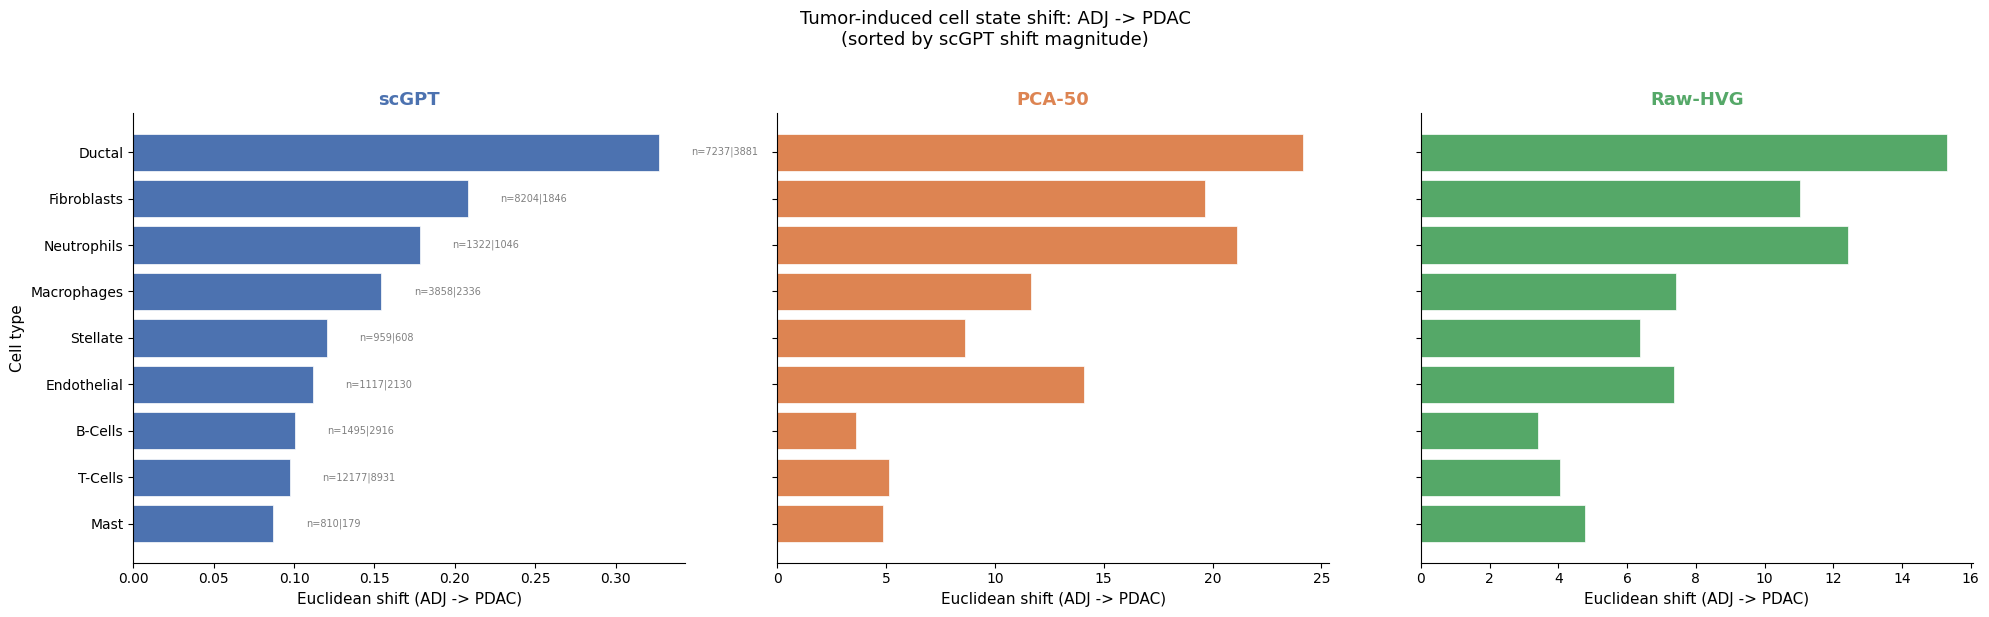

  Saved -> shift_ranking_barplot.png


In [7]:

# ======================================================================
# CELL 5 - Ranked bar plot (all 3 representations)
# ======================================================================

print("\n-- Plotting ranked bar chart ----------------------------------------")

# Order cell types by scGPT euclidean shift (descending)
scgpt_order = (
    shift_df[shift_df["representation"] == "scGPT"]
    .sort_values("euclidean_shift", ascending=False)
    ["cell_type"]
    .tolist()
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
palette = {"scGPT": "#4C72B0", "PCA-50": "#DD8452", "Raw-HVG": "#55A868"}

for ax, rep in zip(axes, ["scGPT", "PCA-50", "Raw-HVG"]):
    sub = (
        shift_df[shift_df["representation"] == rep]
        .set_index("cell_type")
        .reindex(scgpt_order)          # same order across all 3 panels
        .reset_index()
    )
    bars = ax.barh(
        sub["cell_type"],
        sub["euclidean_shift"],
        color=palette[rep],
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_xlabel("Euclidean shift (ADJ -> PDAC)", fontsize=11)
    ax.set_title(rep, fontsize=13, fontweight="bold", color=palette[rep])
    ax.invert_yaxis()                  # largest shift at top
    ax.spines[["top", "right"]].set_visible(False)

    # Annotate cell counts on scGPT panel only
    if rep == "scGPT":
        for bar, (_, row) in zip(bars, sub.iterrows()):
            ax.text(
                bar.get_width() + 0.02,
                bar.get_y() + bar.get_height() / 2,
                f"n={int(row['n_pdac'])}|{int(row['n_adj'])}",
                va="center", fontsize=7, color="gray",
            )

axes[0].set_ylabel("Cell type", fontsize=11)
fig.suptitle(
    "Tumor-induced cell state shift: ADJ -> PDAC\n"
    "(sorted by scGPT shift magnitude)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.savefig("shift_ranking_barplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved -> shift_ranking_barplot.png")


-- Plotting ranked bar chart ----------------------------------------


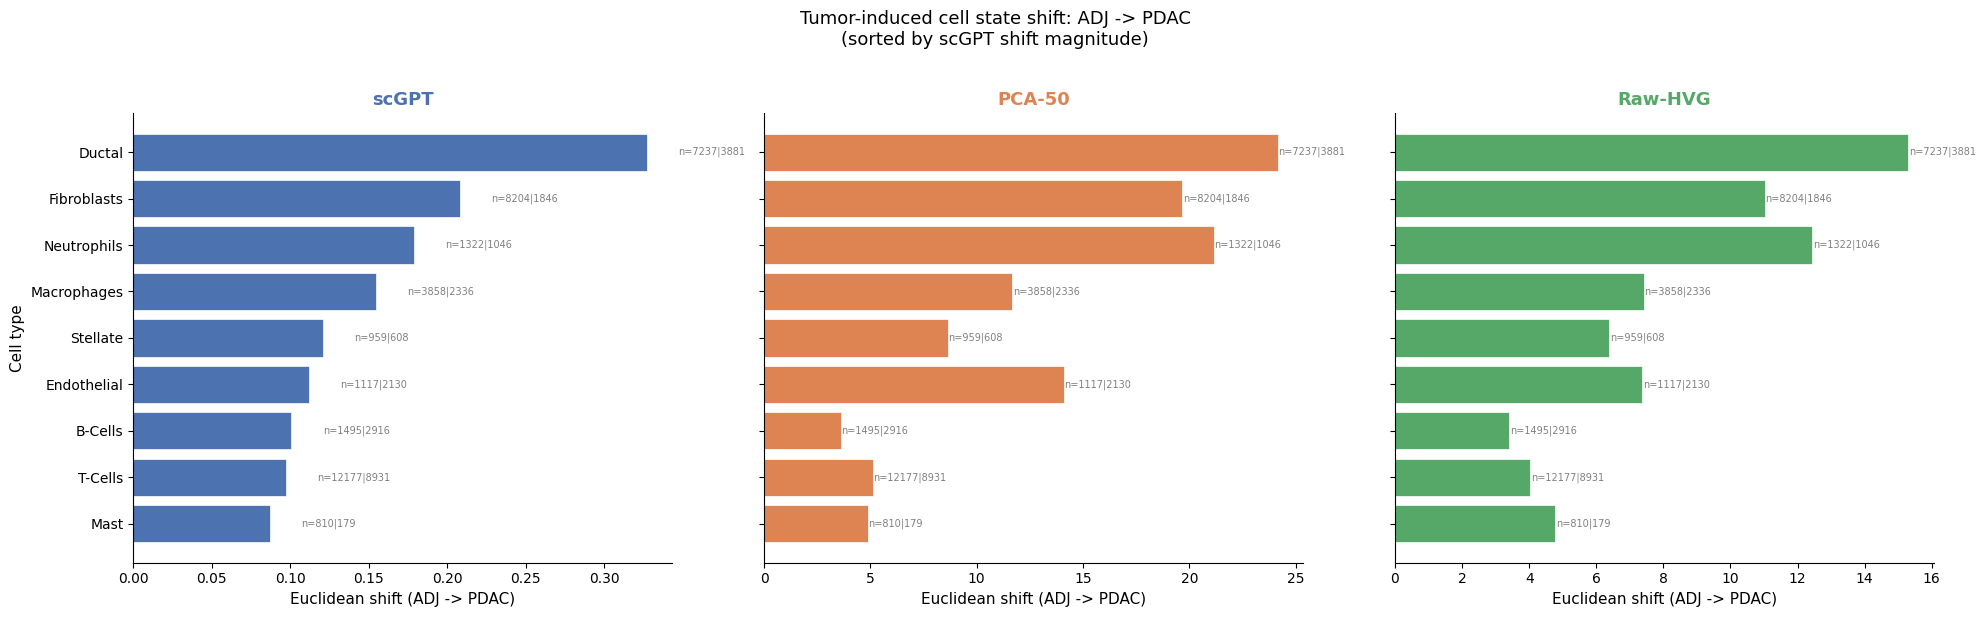

  Saved -> shift_ranking_barplot_per_representation.png


In [8]:

# ======================================================================
# CELL 5 - Ranked bar plot (all 3 representations)
# ======================================================================

print("\n-- Plotting ranked bar chart ----------------------------------------")

# Order cell types by scGPT euclidean shift (descending)
scgpt_order = (
    shift_df[shift_df["representation"] == "scGPT"]
    .sort_values("euclidean_shift", ascending=False)
    ["cell_type"]
    .tolist()
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
palette = {"scGPT": "#4C72B0", "PCA-50": "#DD8452", "Raw-HVG": "#55A868"}

for ax, rep in zip(axes, ["scGPT", "PCA-50", "Raw-HVG"]):
    sub = (
        shift_df[shift_df["representation"] == rep]
        .set_index("cell_type")
        .reindex(scgpt_order)          # same order across all 3 panels
        .reset_index()
    )
    bars = ax.barh(
        sub["cell_type"],
        sub["euclidean_shift"],
        color=palette[rep],
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_xlabel("Euclidean shift (ADJ -> PDAC)", fontsize=11)
    ax.set_title(rep, fontsize=13, fontweight="bold", color=palette[rep])
    ax.invert_yaxis()                  # largest shift at top
    ax.spines[["top", "right"]].set_visible(False)


    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(
          bar.get_width() + 0.02,
          bar.get_y() + bar.get_height() / 2,
          f"n={int(row['n_pdac'])}|{int(row['n_adj'])}",
          va="center", fontsize=7, color="gray",
        )

axes[0].set_ylabel("Cell type", fontsize=11)
fig.suptitle(
    "Tumor-induced cell state shift: ADJ -> PDAC\n"
    "(sorted by scGPT shift magnitude)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.savefig("shift_ranking_barplot_per_representation.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved -> shift_ranking_barplot_per_representation.png")


-- Plotting heatmap -------------------------------------------------


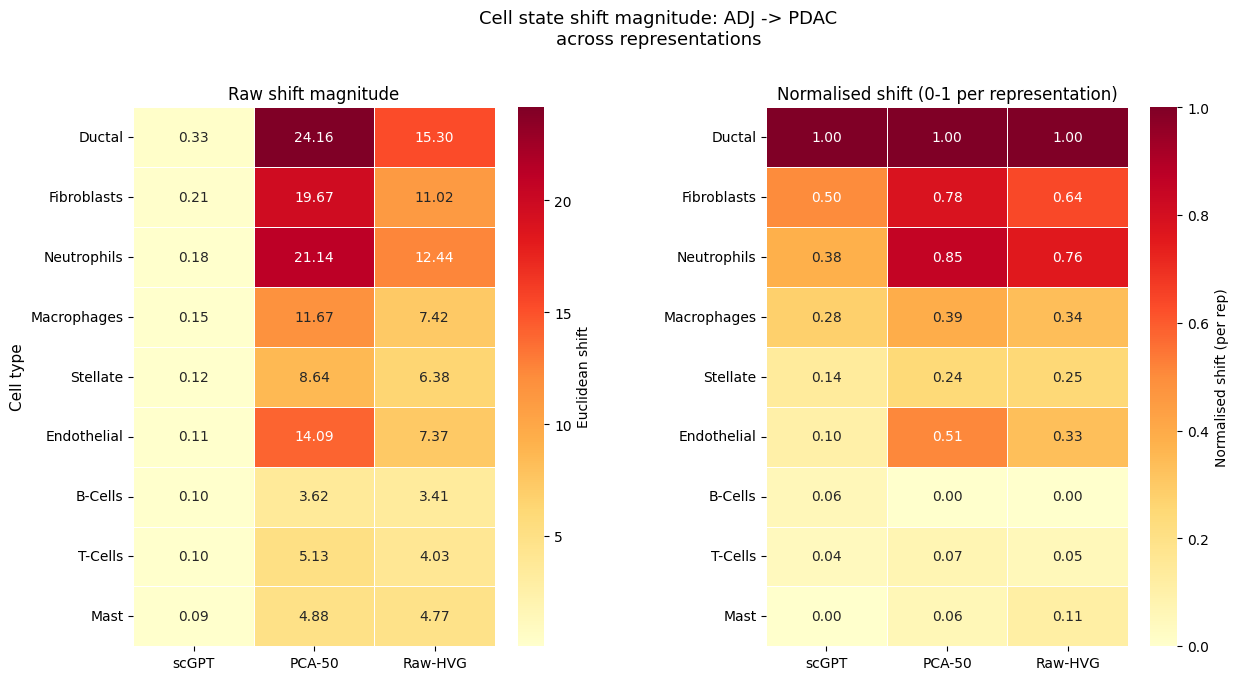

  Saved -> shift_heatmap.png


In [9]:

# ======================================================================
# CELL 6 - Heatmap: cell type x representation
# ======================================================================

print("\n-- Plotting heatmap -------------------------------------------------")

# Pivot to (cell_type x representation) matrix, normalise per rep to [0,1]
# so representations are visually comparable despite different scales
heatmap_data = shift_df.pivot(
    index="cell_type",
    columns="representation",
    values="euclidean_shift",
)[["scGPT", "PCA-50", "Raw-HVG"]]

# Normalise each column to [0, 1] for visual comparison
heatmap_norm = (heatmap_data - heatmap_data.min()) / (
    heatmap_data.max() - heatmap_data.min()
)
heatmap_norm = heatmap_norm.reindex(scgpt_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={"wspace": 0.4})

# Left panel -- raw values
sns.heatmap(
    heatmap_data.reindex(scgpt_order),
    ax=axes[0],
    cmap="YlOrRd",
    annot=True, fmt=".2f",
    linewidths=0.4,
    cbar_kws={"label": "Euclidean shift"},
)
axes[0].set_title("Raw shift magnitude", fontsize=12)
axes[0].set_xlabel("")
axes[0].set_ylabel("Cell type", fontsize=11)

# Right panel -- normalised (0-1 per representation)
sns.heatmap(
    heatmap_norm,
    ax=axes[1],
    cmap="YlOrRd",
    annot=True, fmt=".2f",
    linewidths=0.4,
    cbar_kws={"label": "Normalised shift (per rep)"},
)
axes[1].set_title("Normalised shift (0-1 per representation)", fontsize=12)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

fig.suptitle(
    "Cell state shift magnitude: ADJ -> PDAC\nacross representations",
    fontsize=13, y=1.02,
)
plt.savefig("shift_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved -> shift_heatmap.png")


-- Plotting scGPT vs PCA scatter ------------------------------------


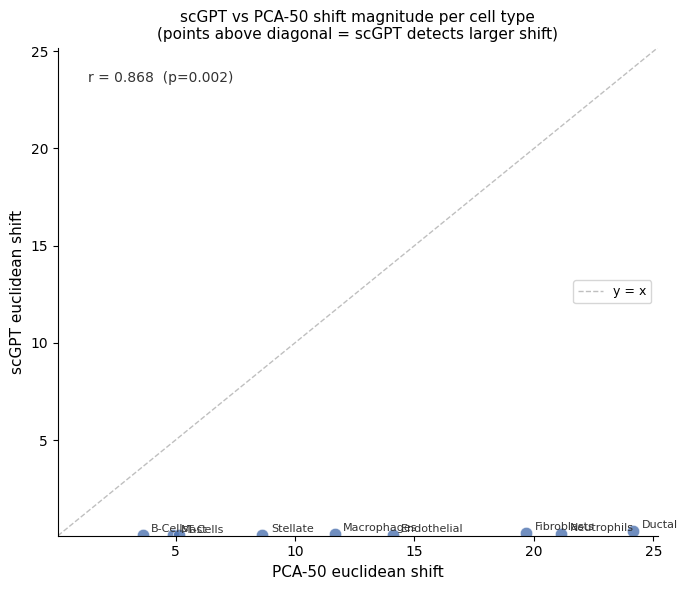

  Saved -> shift_scatter_scgpt_vs_pca.png


In [10]:

# ======================================================================
# CELL 7 - Scatter: scGPT shift vs PCA shift (per cell type)
# ======================================================================

print("\n-- Plotting scGPT vs PCA scatter ------------------------------------")

scgpt_shifts = (
    shift_df[shift_df["representation"] == "scGPT"]
    .set_index("cell_type")["euclidean_shift"]
)
pca_shifts = (
    shift_df[shift_df["representation"] == "PCA-50"]
    .set_index("cell_type")["euclidean_shift"]
)
common_cts = scgpt_shifts.index.intersection(pca_shifts.index)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    pca_shifts[common_cts],
    scgpt_shifts[common_cts],
    s=80, color="#4C72B0", alpha=0.8, edgecolors="white", linewidth=0.5,
)

# Label each point
for ct in common_cts:
    ax.annotate(
        ct,
        (pca_shifts[ct], scgpt_shifts[ct]),
        textcoords="offset points", xytext=(6, 2),
        fontsize=8, color="#333333",
    )

# Diagonal reference line (y=x means equal shift)
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, "--", color="gray", alpha=0.5, linewidth=1, label="y = x")
ax.set_xlim(lims); ax.set_ylim(lims)

# Pearson correlation
from scipy.stats import pearsonr
r, p = pearsonr(pca_shifts[common_cts], scgpt_shifts[common_cts])
ax.text(
    0.05, 0.93,
    f"r = {r:.3f}  (p={p:.3f})",
    transform=ax.transAxes, fontsize=10, color="#333333",
)

ax.set_xlabel("PCA-50 euclidean shift", fontsize=11)
ax.set_ylabel("scGPT euclidean shift", fontsize=11)
ax.set_title(
    "scGPT vs PCA-50 shift magnitude per cell type\n"
    "(points above diagonal = scGPT detects larger shift)",
    fontsize=11,
)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("shift_scatter_scgpt_vs_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved -> shift_scatter_scgpt_vs_pca.png")


-- Plotting scGPT vs PCA scatter ------------------------------------


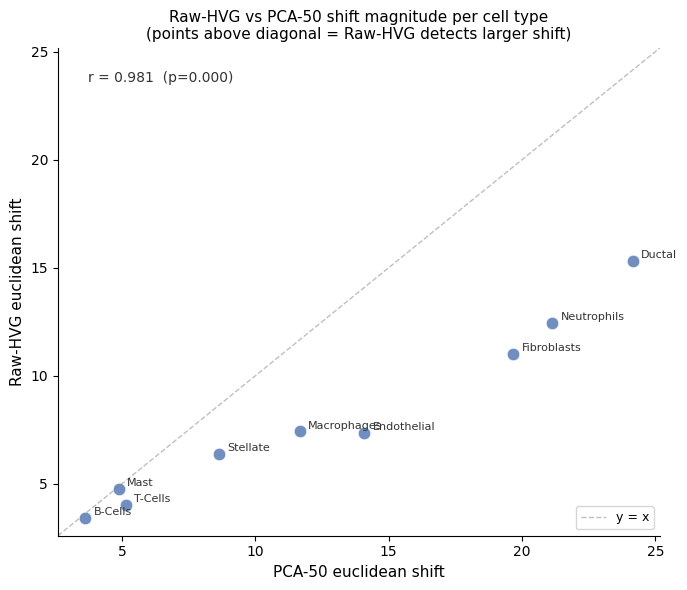

  Saved -> shift_scatter_raw_HVG_vs_pca.png


In [11]:

# ======================================================================
# CELL 7 - Scatter: Raw-HVG shift vs PCA shift (per cell type)
# ======================================================================

print("\n-- Plotting scGPT vs PCA scatter ------------------------------------")

hvg_shifts = (
    shift_df[shift_df["representation"] == "Raw-HVG"]
    .set_index("cell_type")["euclidean_shift"]
)

common_cts = scgpt_shifts.index.intersection(pca_shifts.index)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    pca_shifts[common_cts],
    hvg_shifts[common_cts],
    s=80, color="#4C72B0", alpha=0.8, edgecolors="white", linewidth=0.5,
)

# Label each point
for ct in common_cts:
    ax.annotate(
        ct,
        (pca_shifts[ct], hvg_shifts[ct]),
        textcoords="offset points", xytext=(6, 2),
        fontsize=8, color="#333333",
    )

# Diagonal reference line (y=x means equal shift)
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, "--", color="gray", alpha=0.5, linewidth=1, label="y = x")
ax.set_xlim(lims); ax.set_ylim(lims)

# Pearson correlation
from scipy.stats import pearsonr
r, p = pearsonr(pca_shifts[common_cts], hvg_shifts[common_cts])
ax.text(
    0.05, 0.93,
    f"r = {r:.3f}  (p={p:.3f})",
    transform=ax.transAxes, fontsize=10, color="#333333",
)

ax.set_xlabel("PCA-50 euclidean shift", fontsize=11)
ax.set_ylabel("Raw-HVG euclidean shift", fontsize=11)
ax.set_title(
    "Raw-HVG vs PCA-50 shift magnitude per cell type\n"
    "(points above diagonal = Raw-HVG detects larger shift)",
    fontsize=11,
)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("shift_scatter_raw_hvg_vs_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved -> shift_scatter_raw_HVG_vs_pca.png")

In [12]:
# Ratio of max to min shift -- higher = sharper discrimination
for rep in ["scGPT", "PCA-50", "Raw-HVG"]:
    sub = shift_df[shift_df["representation"] == rep]["euclidean_shift"]
    print(f"{rep:10s}  max/min ratio = {sub.max()/sub.min():.2f}")

scGPT       max/min ratio = 3.75
PCA-50      max/min ratio = 6.67
Raw-HVG     max/min ratio = 4.48


In [22]:
!pip install adjustText -q


-- Plotting UMAP with shift vectors (scGPT) -------------------------


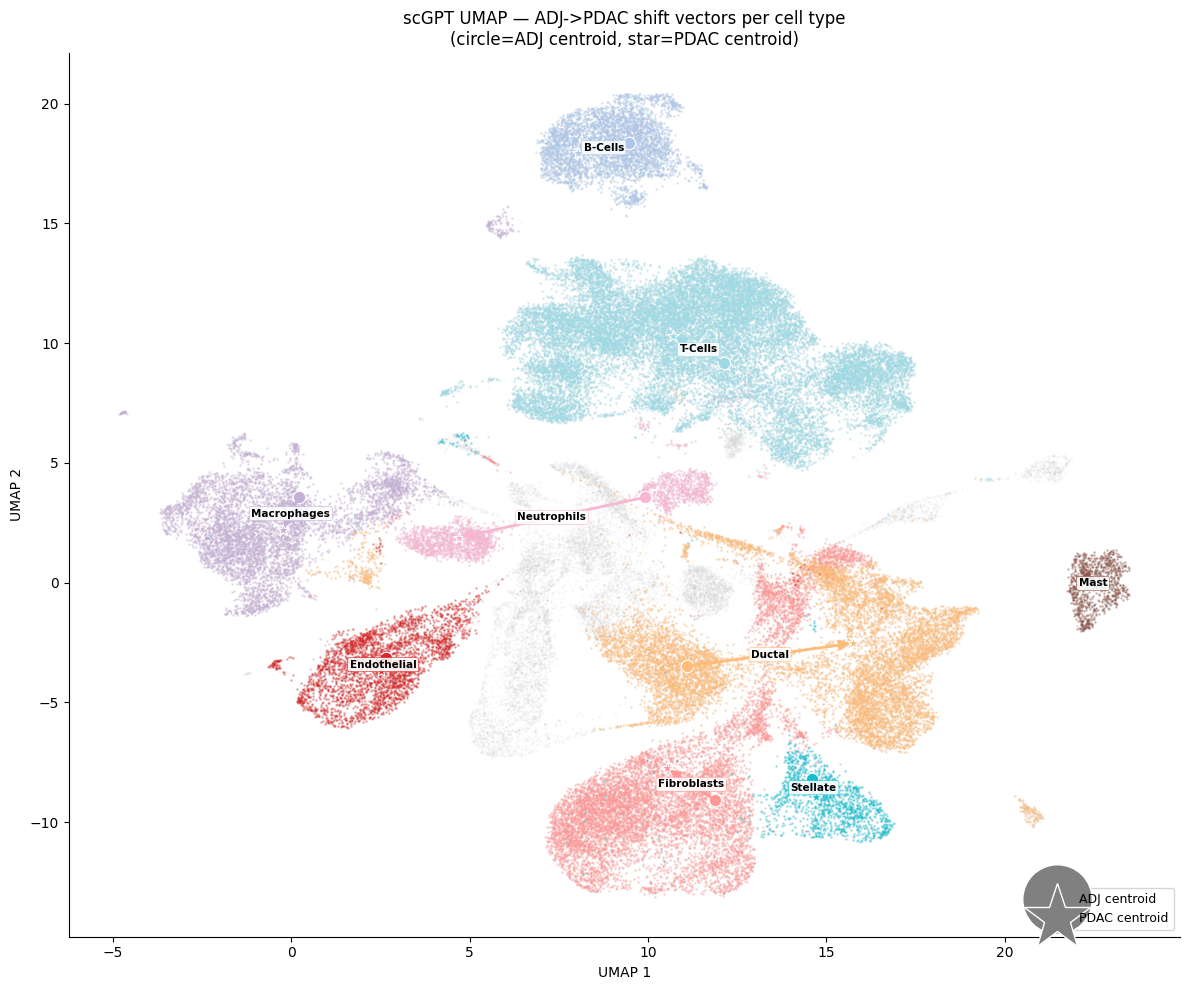

In [21]:
# ======================================================================
# CELL 8 - UMAP with ADJ/PDAC centroids per cell type (scGPT space)
# ======================================================================

print("\n-- Plotting UMAP with shift vectors (scGPT) -------------------------")

# Use the scGPT UMAP computed in Notebook 2
umap_key = "X_umap_X_scgpt"
if umap_key not in adata.obsm:
    print(f"  '{umap_key}' not found, recomputing UMAP on scGPT embeddings...")
    sc.pp.neighbors(adata, use_rep="X_scgpt", n_neighbors=15,
                    random_state=RANDOM_STATE)
    sc.tl.umap(adata, random_state=RANDOM_STATE)
    adata.obsm[umap_key] = adata.obsm["X_umap"].copy()

umap_coords = adata.obsm[umap_key]   # (n_cells, 2)

fig, ax = plt.subplots(figsize=(12, 10))

# 1. Background — all cells in gray
ax.scatter(
    umap_coords[:, 0], umap_coords[:, 1],
    s=0.3, c="lightgray", alpha=0.2, rasterized=True, zorder=1,
)

scgpt_vecs = vectors_df[vectors_df["representation"] == "scGPT"]

for _, row in scgpt_vecs.iterrows():
    ct    = row["cell_type"]
    color = colors[ct]

    mask_ct   = (adata.obs[CELL_TYPE_KEY] == ct).values
    mask_adj  = mask_ct & (adata.obs["condition"] == "ADJ").values
    mask_pdac = mask_ct & (adata.obs["condition"] == "PDAC").values

    if mask_adj.sum() < MIN_CELLS or mask_pdac.sum() < MIN_CELLS:
        continue

    # 2. Colored cell type points
    ax.scatter(
        umap_coords[mask_ct, 0], umap_coords[mask_ct, 1],
        s=0.8, c=[color], alpha=0.3, rasterized=True, zorder=2,
    )

    c_adj  = umap_coords[mask_adj].mean(axis=0)
    c_pdac = umap_coords[mask_pdac].mean(axis=0)

    # 3. Centroid markers — large dots so they're visible
    ax.scatter(*c_adj,  s=80, color=color, marker="o",
               edgecolors="white", linewidth=0.8, zorder=4)
    ax.scatter(*c_pdac, s=80, color=color, marker="*",
               edgecolors="white", linewidth=0.8, zorder=4)

    # 4. Arrow from ADJ centroid to PDAC centroid
    ax.annotate(
        "", xy=c_pdac, xytext=c_adj,
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=2.0,
            mutation_scale=15,
        ),
        zorder=5,
    )

    # 5. Label at midpoint — slightly offset to avoid arrow overlap
    mid = (c_adj + c_pdac) / 2
    ax.text(
        mid[0], mid[1], ct,
        fontsize=7.5, color="black", fontweight="bold",
        ha="center", va="center", zorder=6,
        bbox=dict(boxstyle="round,pad=0.2", fc="white",
                  alpha=0.85, lw=0.5, edgecolor=color),
    )

# Legend: circle = ADJ, star = PDAC
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markersize=50, label="ADJ centroid"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="gray",
           markersize=50, label="PDAC centroid"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

ax.set_title(
    "scGPT UMAP — ADJ->PDAC shift vectors per cell type\n"
    "(circle=ADJ centroid, star=PDAC centroid)",
    fontsize=12,
)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("umap_shift_vectors.png", dpi=150, bbox_inches="tight")
plt.show()

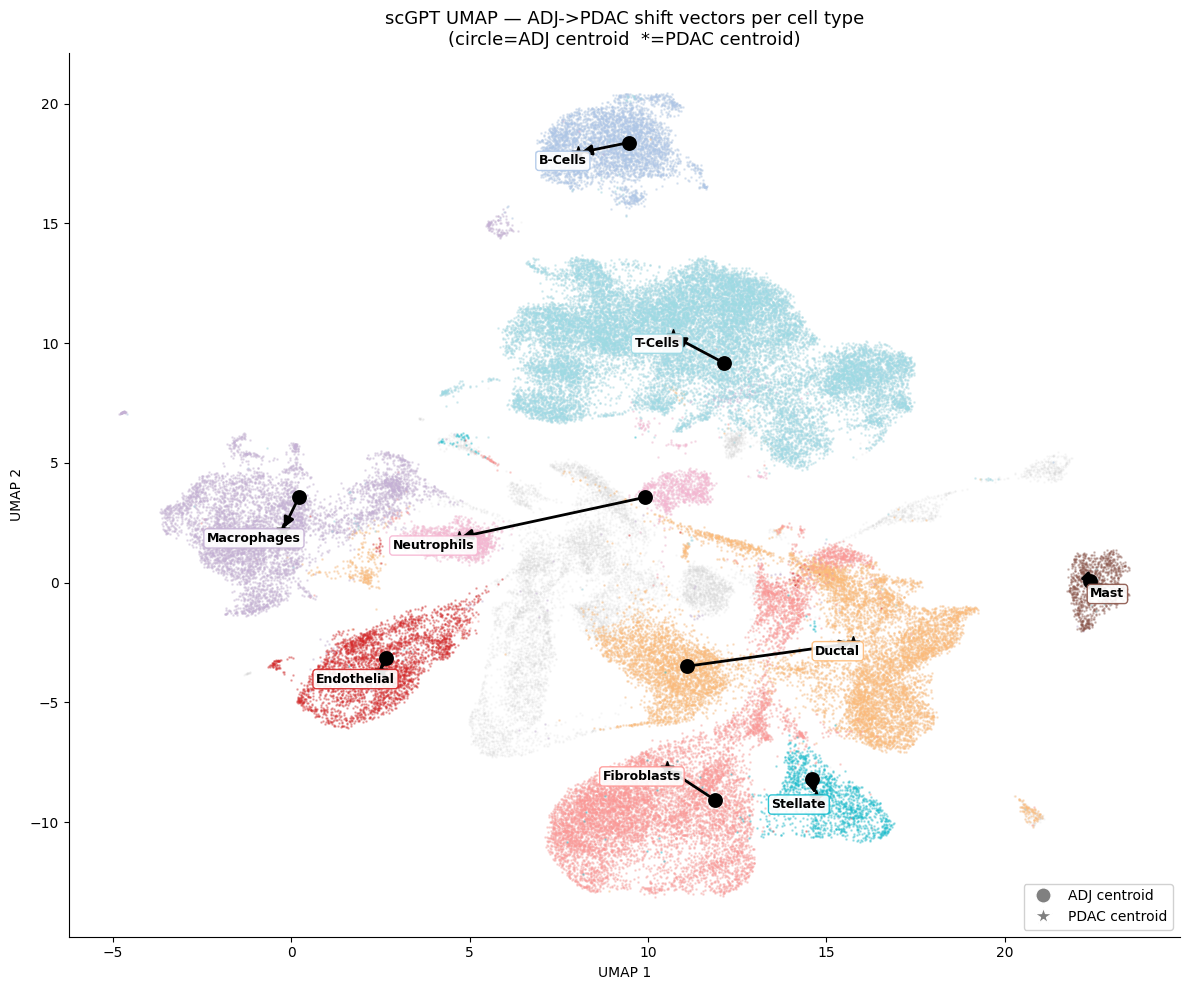

In [34]:
from adjustText import adjust_text
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(12, 10))

# 1. Background
ax.scatter(
    umap_coords[:, 0], umap_coords[:, 1],
    s=0.3, c="lightgray", alpha=0.2, rasterized=True, zorder=1,
)

scgpt_vecs = vectors_df[vectors_df["representation"] == "scGPT"]
texts = []   # collect for adjustText

for _, row in scgpt_vecs.iterrows():
    ct    = row["cell_type"]
    color = colors[ct]

    mask_ct   = (adata.obs[CELL_TYPE_KEY] == ct).values
    mask_adj  = mask_ct & (adata.obs["condition"] == "ADJ").values
    mask_pdac = mask_ct & (adata.obs["condition"] == "PDAC").values

    if mask_adj.sum() < MIN_CELLS or mask_pdac.sum() < MIN_CELLS:
        continue

    # 2. Colored cells
    ax.scatter(
        umap_coords[mask_ct, 0], umap_coords[mask_ct, 1],
        s=0.8, c=[color], alpha=0.3, rasterized=True, zorder=2,
    )

    c_adj  = umap_coords[mask_adj].mean(axis=0)
    c_pdac = umap_coords[mask_pdac].mean(axis=0)

    # 3. Centroid markers
    ax.scatter(*c_adj,  s=90, color="black", marker="o",
               edgecolors="black", linewidth=1.2, zorder=4)
    ax.scatter(*c_pdac, s=90, color="black", marker="*",
               edgecolors="black", linewidth=1.2, zorder=4)

    # 4. Arrow
    ax.annotate(
        "", xy=c_pdac, xytext=c_adj,
        arrowprops=dict(
            arrowstyle="-|>", color="black",
            lw=2.0, mutation_scale=15,
        ),
        zorder=5,
    )

    # 5. Collect labels at PDAC centroid (end of arrow)
    t = ax.text(
        c_pdac[0], c_pdac[1], ct,
        fontsize=9, color="black", fontweight="bold",
        ha="center", va="center", zorder=6,
        bbox=dict(boxstyle="round,pad=0.25", fc="white",
                  alpha=0.9, lw=1.0, edgecolor=color),
    )
    texts.append(t)

# 6. Auto-adjust label positions to avoid overlap
adjust_text(
    texts,
    ax=ax,
    expand_text=(1.5, 1.5),
    expand_points=(1.2, 1.2),
    force_text=(0.5, 0.5),
    arrowprops=dict(arrowstyle="-", color="gray",
                    lw=0.8, alpha=0.6),
)

# Legend
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markersize=11, label="ADJ centroid"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="gray",
           markersize=13, label="PDAC centroid"),
]
ax.legend(handles=legend_elements, loc="lower right",
          fontsize=10, framealpha=0.9)

ax.set_title(
    "scGPT UMAP — ADJ->PDAC shift vectors per cell type\n"
    "(circle=ADJ centroid  *=PDAC centroid)",
    fontsize=13,
)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("umap_shift_vectors.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# ======================================================================
# CELL 9 - Summary statistics
# ======================================================================

print("\n-- Summary ----------------------------------------------------------")

print("\nTop 5 most shifted cell types (scGPT, euclidean):")
print(
    shift_df[shift_df["representation"] == "scGPT"]
    .sort_values("euclidean_shift", ascending=False)
    [["cell_type", "euclidean_shift", "cosine_shift", "n_pdac", "n_adj"]]
    .head(5)
    .to_string(index=False)
)

print("\nMean shift across all cell types:")
print(
    shift_df.groupby("representation")["euclidean_shift"]
    .agg(["mean", "std", "min", "max"])
    .round(3)
    .to_string()
)

print("\nRepresentation ranking by mean shift magnitude:")
ranking = (
    shift_df.groupby("representation")["euclidean_shift"]
    .mean()
    .sort_values(ascending=False)
)
for i, (rep, val) in enumerate(ranking.items(), 1):
    print(f"  {i}. {rep:10s}  mean shift = {val:.3f}")

print("\nDone. Next: 04_classification_eval.py")


-- Summary ----------------------------------------------------------

Top 5 most shifted cell types (scGPT, euclidean):
  cell_type  euclidean_shift  cosine_shift  n_pdac  n_adj
     Ductal         0.327001      0.059276    7237   3881
Fibroblasts         0.207993      0.024786    8204   1846
Neutrophils         0.178510      0.016661    1322   1046
Macrophages         0.154349      0.014197    3858   2336
   Stellate         0.120540      0.008031     959    608

Mean shift across all cell types:
                  mean    std    min     max
representation                              
PCA-50          12.556  7.676  3.619  24.156
Raw-HVG          8.017  4.074  3.413  15.305
scGPT            0.154  0.077  0.087   0.327

Representation ranking by mean shift magnitude:
  1. PCA-50      mean shift = 12.556
  2. Raw-HVG     mean shift = 8.017
  3. scGPT       mean shift = 0.154

Done. Next: 04_classification_eval.py
